# Electing Applicants for Loans

## 1. Importing the required libraries

In [2]:
import pandas as pd
import tabula
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.preprocessing import LabelEncoder

## 2. Loading the Data

In [3]:
first_dataset = pd.read_csv("datasets/ELECT Loan Data.csv")
first_dataset.head()

,Loan_ID,Gender,Married,Dependents,Graduate,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,2284,1,0,0,0,0,3902,1666.0,109,333,1,3,Y
1,2287,2,0,0,1,0,1500,1800.0,103,333,0,2,N
2,2288,1,1,2,0,0,2889,0.0,45,180,0,1,N
3,2296,1,0,0,0,0,2755,0.0,65,300,1,3,N
4,2297,1,0,0,1,0,2500,20000.0,103,333,1,2,Y


In [4]:
second_dataset = tabula.read_pdf("datasets/ELECT_Loans_Database_Table.pdf", pages="all", multiple_tables=False)[0]
second_dataset.head()

,Loan_ID,Gender,Married,Dependents,Graduate,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1002,1,0,0,1,0,5849,0.0,128,360,1,1,Y
1,1003,1,1,1,1,0,4583,1508.0,128,360,1,3,N
2,1005,1,1,0,1,1,3000,0.0,66,360,1,1,Y
3,1006,1,1,0,0,0,2583,2358.0,120,360,1,1,Y
4,1008,1,0,0,1,0,6000,0.0,141,360,1,1,Y


In [5]:
dataset = pd.concat([first_dataset, second_dataset], ignore_index=True)
dataset.head()

,Loan_ID,Gender,Married,Dependents,Graduate,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,2284,1,0,0,0,0,3902,1666.0,109,333,1,3,Y
1,2287,2,0,0,1,0,1500,1800.0,103,333,0,2,N
2,2288,1,1,2,0,0,2889,0.0,45,180,0,1,N
3,2296,1,0,0,0,0,2755,0.0,65,300,1,3,N
4,2297,1,0,0,1,0,2500,20000.0,103,333,1,2,Y


The first dataset is a CSV file, so we can easily load it using the pandas function `read_csv()`, and specifying the path to the file.

Now, the second dataset is a PDF file. To obtain the data from the PDF, we import the **tabula** library, and use the `read_pdf()` function to obtain the `DataFrame` for the data.

In [6]:
dataset.tail()

,Loan_ID,Gender,Married,Dependents,Graduate,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
640,2265,1,1,2,0,0,1993,1625.0,113,180,1,2,Y
641,2266,1,1,2,1,0,3100,1400.0,113,360,1,1,Y
642,2272,1,1,2,1,0,3276,484.0,135,360,0,2,Y
643,2277,2,0,0,1,0,3180,0.0,71,360,0,1,N
644,2281,1,1,0,1,0,3033,1459.0,95,360,1,1,Y


---

## 3. Preprocessing the Data

We can see that the rows are not in a definitive order after the two datasets were concatenated into one.

So, we can sort the rows based on the `Loan_ID` column.

In [7]:
dataset = dataset.sort_values("Loan_ID").reset_index(drop=True)
dataset.head()

,Loan_ID,Gender,Married,Dependents,Graduate,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1002,1,0,0,1,0,5849,0.0,128,360,1,1,Y
1,1003,1,1,1,1,0,4583,1508.0,128,360,1,3,N
2,1005,1,1,0,1,1,3000,0.0,66,360,1,1,Y
3,1006,1,1,0,0,0,2583,2358.0,120,360,1,1,Y
4,1008,1,0,0,1,0,6000,0.0,141,360,1,1,Y


Now, we'll check for inconsistencies and missing values in the data.

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 645 entries, 0 to 644
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            645 non-null    int64  
 1   Gender             645 non-null    int64  
 2   Married            645 non-null    int64  
 3   Dependents         645 non-null    int64  
 4   Graduate           645 non-null    int64  
 5   Self_Employed      645 non-null    int64  
 6   ApplicantIncome    645 non-null    int64  
 7   CoapplicantIncome  645 non-null    float64
 8   LoanAmount         645 non-null    int64  
 9   Loan_Amount_Term   645 non-null    int64  
 10  Credit_History     645 non-null    int64  
 11  Property_Area      645 non-null    int64  
 12  Loan_Status        645 non-null    object 
dtypes: float64(1), int64(11), object(1)
memory usage: 65.6+ KB


This shows that there are no missing values present in any of the columns.

Let's now see the distribution of values in each numeric column.

TypeError: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

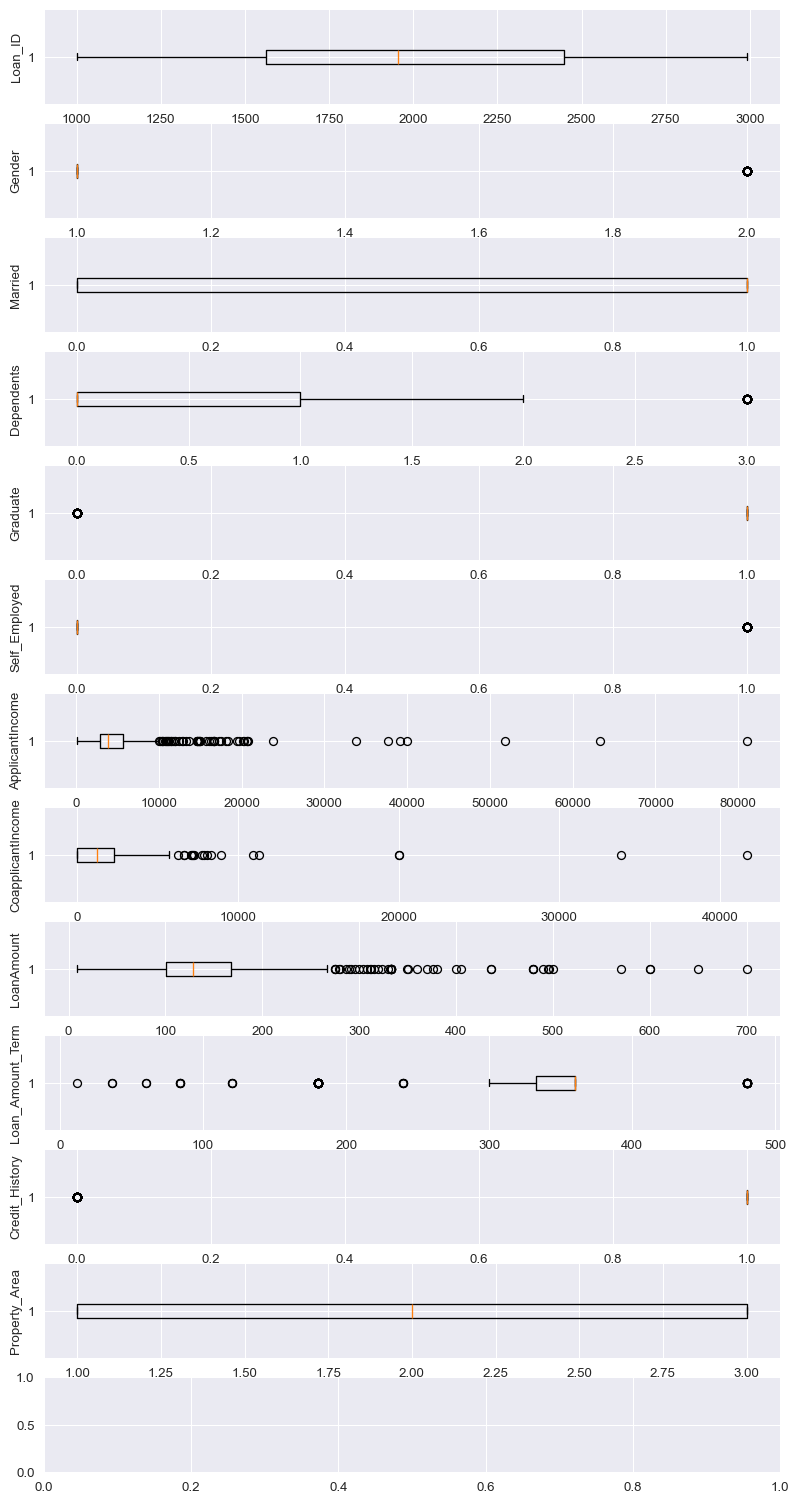

In [9]:
fig, ax = plt.subplots(13, 1, dpi=95, figsize=(10, 20))

for index, col in enumerate(dataset.columns):
    ax[index].boxplot(dataset[col], vert=False)
    ax[index].set_ylabel(col)

plt.show()

Here, we can see the last boxplot is empty, even though there are 13 columns (one column for one boxplot). This is because the last column is of an object type, depicting if the customer received the loan or not using "Y" and "N".

Since it has only two possible values ("Y" and "N"), we can encode it to an integer (either 1 or 0). We can do this using a `LabelEncoder`.

In [10]:
encoder = LabelEncoder()

dataset["Loan_Status"] = encoder.fit_transform(dataset["Loan_Status"])
dataset["Loan_Status"].head()

0    1
1    0
2    1
3    1
4    1
Name: Loan_Status, dtype: int64

Now that we have the column values in a binary format (1 or 0), we can obtain the correlation table for all columns, which will be helpful to understand the features (columns) that are more correlated to the `Loan_Status` column than others.

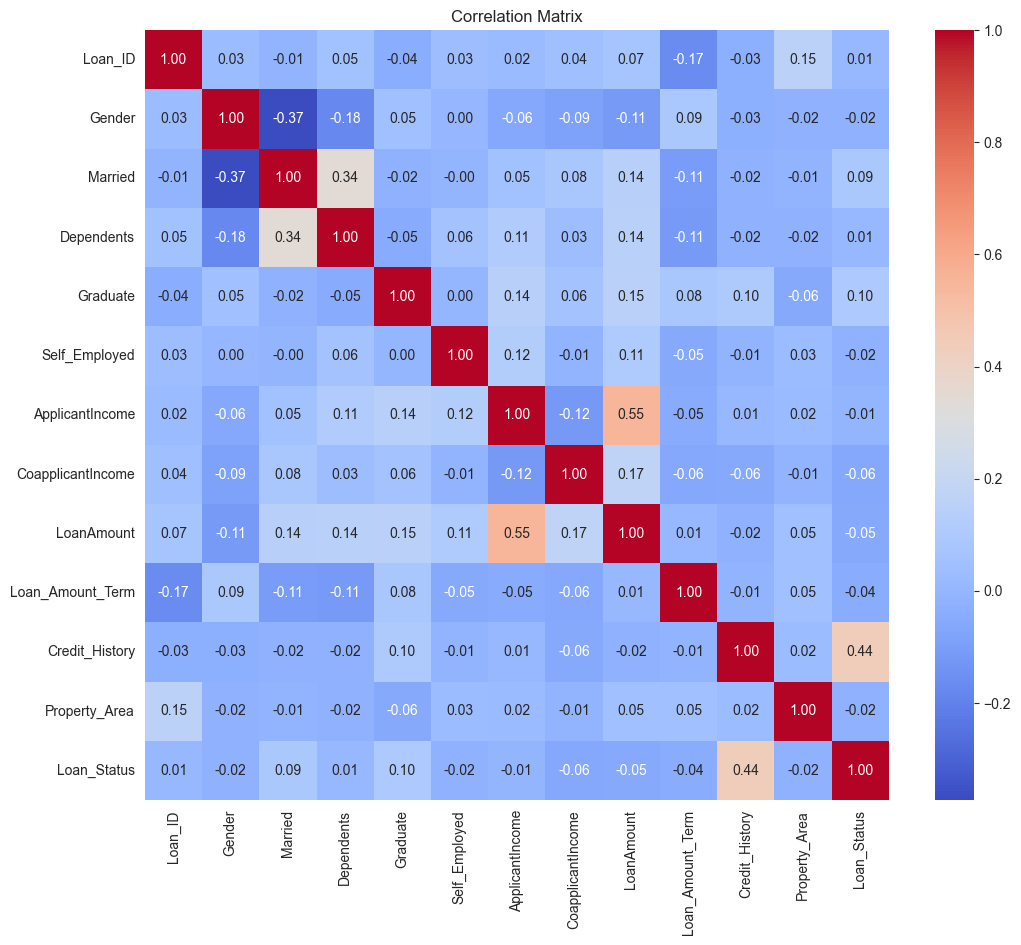

In [11]:
corr_matrix = dataset.corr()

plt.figure(figsize=(12, 10))
sb.heatmap(corr_matrix, annot=True, fmt="0.2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

---

## 4. Exploratory Data Analysis

Q. **Total amount** loaned by EFS.

In [12]:
print(f"Total Amount Loaned by EFS: ${dataset["LoanAmount"].sum()}")

Total Amount Loaned by EFS: $95557


Q. **Average amount** loaned by EFS.

In [13]:
print("Average Amount Loaned by EFS: ${0:.2f}".format(dataset["LoanAmount"].mean()))

Average Amount Loaned by EFS: $148.15


Q. **Average** loan term.

In [14]:
print(f"Average Loan Term: {round(dataset["Loan_Amount_Term"].mean())} days")

Average Loan Term: 335 days


Q. The total number of applicants broken down into Approved and Rejected, the number of males and females in each case, and shown in an appropriate chart.

In [15]:
total_applicants_by_status = dataset["Loan_Status"].value_counts()
total_applicants_by_status.index = total_applicants_by_status.index.map({
    1: "Approved",
    0: "Rejected"
})

total_applicants_by_status.name = "Total Applicants"
total_applicants_by_status

Loan_Status
Approved    444
Rejected    201
Name: Total Applicants, dtype: int64

In [17]:
gender_and_status = dataset.groupby(["Gender", "Loan_Status"]).size()

gender_and_status.index = gender_and_status.index.set_levels(
    [
        gender_and_status.index.levels[0].map({1: "Male", 2: "Female"}),
        gender_and_status.index.levels[1].map({1: "Approved", 0: "Rejected"})
    ]
)

gender_and_status.name = "Total Applicants"
gender_and_status.reset_index()

,Gender,Loan_Status,Total Applicants
0,Male,Rejected,161
1,Male,Approved,364
2,Female,Rejected,40
3,Female,Approved,80


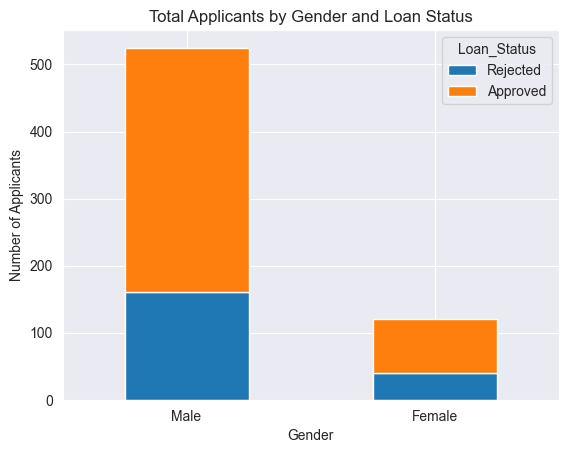

In [18]:
gender_n_status_unstacked = gender_and_status.unstack()

gender_n_status_unstacked.plot(kind="bar", stacked=True)

plt.title("Total Applicants by Gender and Loan Status")
plt.xlabel("Gender")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.show()

Q. The maximum and minimum of amounts loaned and shown in an appropriate chart.

In [19]:
amount_loaned: pd.DataFrame = dataset["LoanAmount"].agg(["min", "max"]).reset_index()
amount_loaned = amount_loaned.rename({"index": "Min_Max"}, axis="columns")
amount_loaned

,Min_Max,LoanAmount
0,min,9
1,max,700


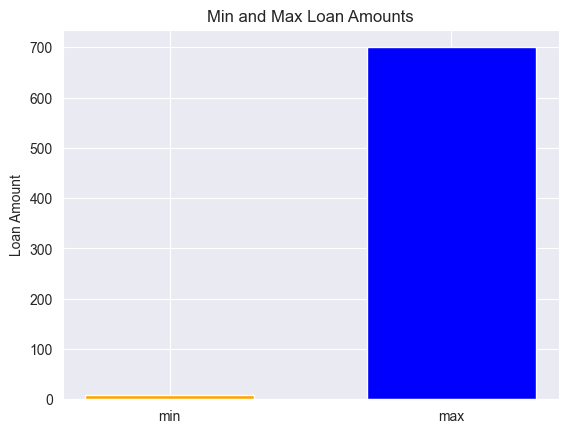

In [20]:
plt.bar(amount_loaned["Min_Max"], amount_loaned['LoanAmount'], width=0.6, color=["orange", "blue"])
plt.title("Min and Max Loan Amounts")
plt.ylabel("Loan Amount")
plt.show()

Q. The number of self-employed who had their loan approved, expressed as a percentage of all who had their loan approved, and shown in an appropriate chart.

In [21]:
self_employed_approved = int(dataset.loc[(dataset["Self_Employed"] == 1) & (dataset["Loan_Status"] == 1)]["Loan_ID"].count())

total_approved = int(dataset.loc[dataset["Self_Employed"] == 1]["Loan_ID"].count())

print("Number of Self-Employed Applicants who had their Loan Approved:", self_employed_approved)
print("Self-Employed Approved out of Total Approved Applicants: {0:.2f}%".format((self_employed_approved / total_approved) * 100))

Number of Self-Employed Applicants who had their Loan Approved: 56
Self-Employed Approved out of Total Approved Applicants: 66.67%


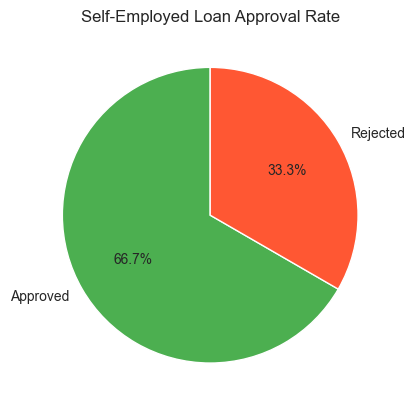

In [24]:
plt.pie([self_employed_approved, total_approved - self_employed_approved], labels=["Approved", "Rejected"], autopct="%1.1f%%", startangle=90, colors=['#4CAF50', '#FF5733'])
plt.title("Self-Employed Loan Approval Rate")
plt.show()

Q. Income distribution of all main applicants, showing average and standard deviation.

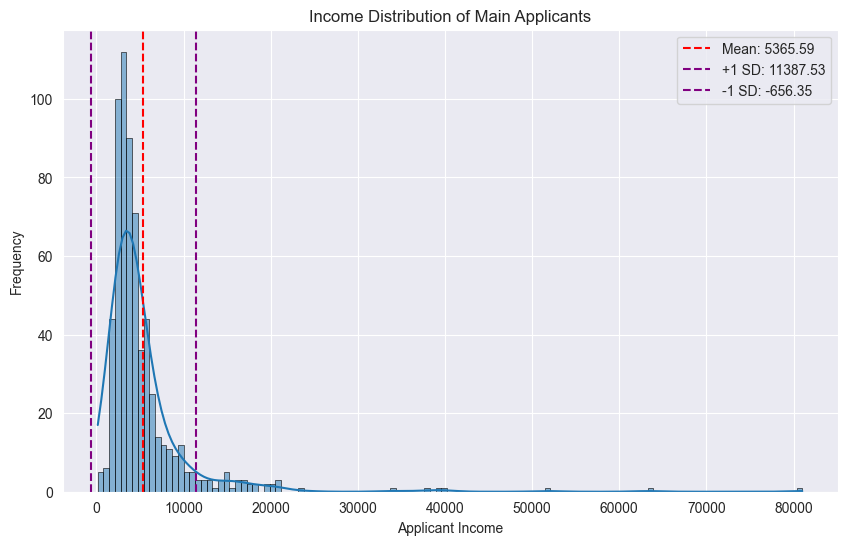

In [29]:
mean_income = dataset["ApplicantIncome"].mean()
std_income = dataset["ApplicantIncome"].std()

plt.figure(figsize=(10, 6))
sb.histplot(data=dataset, x="ApplicantIncome", kde=True, edgecolor="black")

plt.axvline(mean_income, color="red", linestyle="--", label=f"Mean: {mean_income:.2f}")
plt.axvline(mean_income + std_income, color="purple", linestyle="--", label=f'+1 SD: {mean_income + std_income:.2f}')
plt.axvline(mean_income - std_income, color="purple", linestyle="--", label=f'-1 SD: {mean_income - std_income:.2f}')

plt.title("Income Distribution of Main Applicants")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")
plt.legend()

plt.show()

Q. Top 10 applicants by loan amount.

In [32]:
top_10_loan_amt = dataset[["Loan_ID", "LoanAmount"]].sort_values("LoanAmount", ascending=False)[:10].reset_index(drop=True)
top_10_loan_amt

,Loan_ID,LoanAmount
0,1585,700
1,1469,650
2,2813,600
3,1536,600
4,2191,570
5,2547,500
6,2959,496
7,1610,495
8,2101,490
9,1996,480
